<a href="https://colab.research.google.com/github/MayaLakshmanaprabu/Maya-Priyadharshini-Lakshmanaprabu/blob/Python/Home_L10_Data_Visualisation_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home Assignment

### Let’s take the data-visualisation techniques we learned and use them on a real dataset you’re already familiar with. You’ll see how visualisation speeds up data cleaning, helps us spot patterns faster, and makes communicating insights much easier.

# **Apartment cost and sizes in Germany**

**Where is the data from?**

The data was scraped from Immoscout24, the biggest real estate platform in Germany. Immoscout24 has listings for both rental properties and homes for sale, however, the data only contains offers for rental properties.
The scraping process is described in this blog post and the corresponding code for scraping and minimal processing afterwards can be found in this Github repo.
At a given time, all available offers were scraped from the site and saved. This process was repeated three times, so the data set contains offers from the dates 2018-09-22, 2019-05-10 and 2019-10-08.

**Content**

The data set contains most of the important properties, such as living area size, the rent, both base rent as well as total rent (if applicable), the location (street and house number, if available, ZIP code and state), type of energy etc. It also has two variables containing longer free text descriptions: description with a text describing the offer and facilities describing all available facilities, newest renovation etc. The date column was added to give the time of scraping.

**Inspiration**

Did rents increase over time? Which areas are the most expensive? Which areas saw the largest increase, which areas became cheaper? Are there any duplicates? How many? What could be gained from a text analysis of the free text variables?

**Acknowledgements**

The data belongs to www.immobilienscount24.de and is for research purposes only. The data was created with .


**Here you can find the data -->**

https://www.kaggle.com/datasets/corrieaar/apartment-rental-offers-in-germany


Let's first read the data:

In [1]:
import pandas as pd
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("corrieaar/apartment-rental-offers-in-germany")
csv_path = f"{path}/immo_data.csv"
df = pd.read_csv(csv_path)

100%|██████████| 93.0M/93.0M [00:00<00:00, 146MB/s]

Extracting files...


### Is the dataset complete?

1. Let's check **% of null values for each column** using a *barplot*

In [3]:
null_percent = df.isnull().sum() / len(df) * 100
print(null_percent.sort_values(ascending=False))

telekomHybridUploadSpeed    83.254603
electricityBasePrice        82.575414
electricityKwhPrice         82.575414
energyEfficiencyClass       71.066766
lastRefurbish               69.979171
heatingCosts                68.191185
noParkSpaces                65.388879
petsAllowed                 42.615957
interiorQual                41.906267
thermalChar                 39.615399
numberOfFloors              36.351869
houseNumber                 26.415473
streetPlain                 26.413614
condition                   25.474800
yearConstructed             21.218151
yearConstructedRange        21.218151
firingTypes                 21.188023
facilities                  19.685326
floor                       19.084620
heatingType                 16.684397
totalRent                   15.070485
typeOfFlat                  13.618747
telekomUploadSpeed          12.407662
telekomTvOffer              12.132788
description                  7.344988
serviceCharge                2.569834
pricetrend  

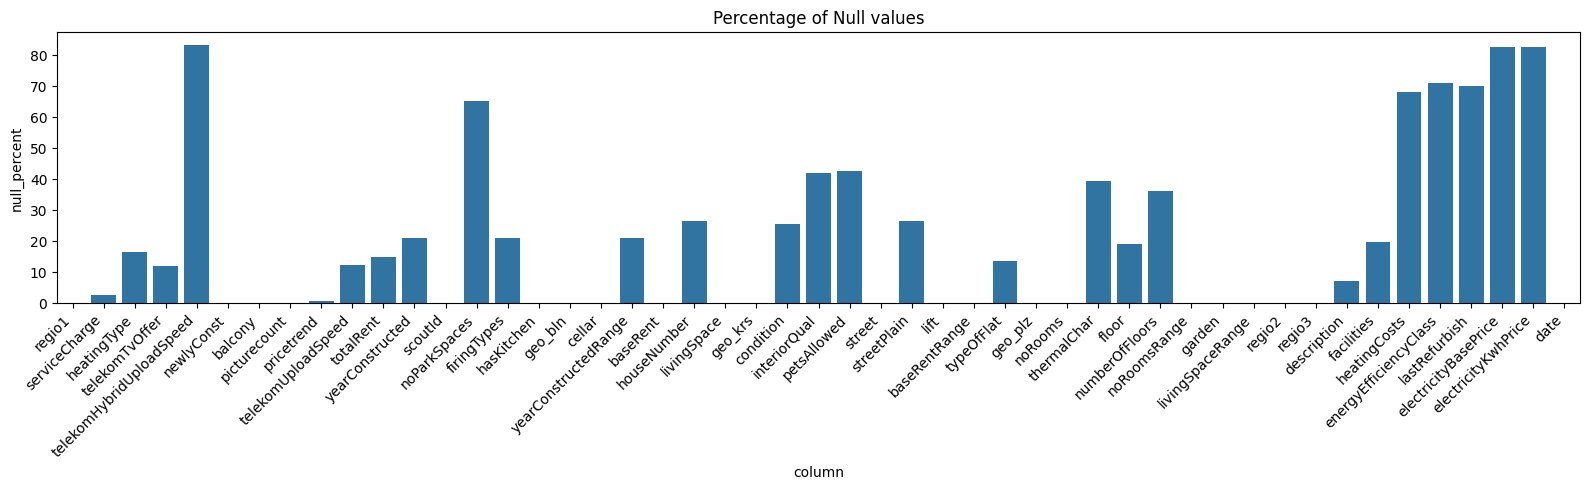

In [10]:
null_df = null_percent.reset_index()
null_df.columns = ['column', 'null_percent']

plt.figure(figsize=(16,5))
sns.barplot(data=null_df,x='column',y='null_percent')
plt.xticks(rotation=45,ha='right')
plt.title('Percentage of Null values')
plt.tight_layout()
plt.show()



2. **Number of listings per date** (to check whether some dates have too little data to be meaningful, or whether the timeline is unevenly populated and could distort the overall picture) using a *lineplot*

        date  count
0 2018-09-01  46842
1 2019-05-01  76047
2 2019-10-01  66685
3 2020-02-01  79276


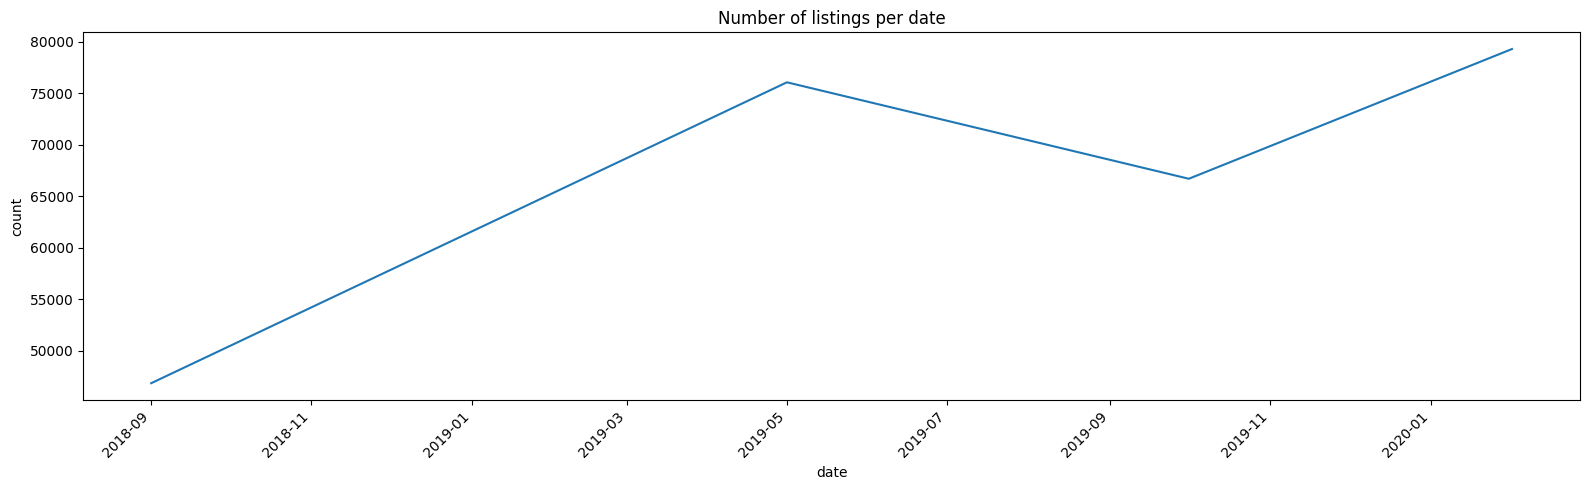

In [16]:
df['date'] =pd.to_datetime(df['date'],format='%b%y') #format (%b - abbreviated month) , (%y- 2 digit year)

list_per_date =df.groupby('date').size().reset_index()
list_per_date.columns = ['date','count']
print(list_per_date.head(10))

plt.figure(figsize=(16,5))
sns.lineplot(data=list_per_date,x='date',y='count')
plt.xticks(rotation=45,ha='right')
plt.title('Number of listings per date')
plt.tight_layout()
plt.show()


3. Let's check which **condition types** are the flats in, using *countplot*

/tmp/ipykernel_1239/429318565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='condition', order=df['condition'].value_counts().index, palette='tab10')


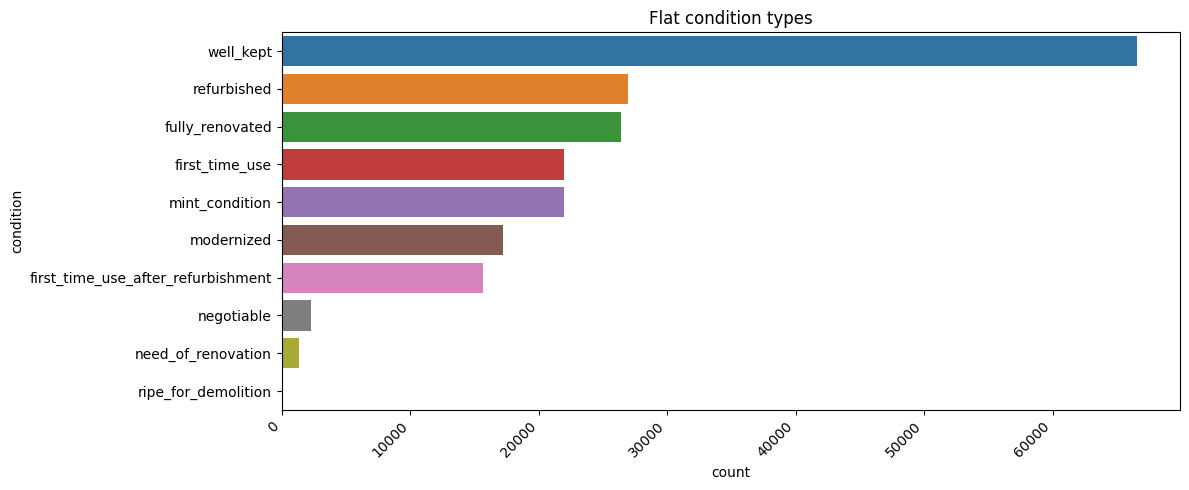

In [24]:
plt.figure(figsize=(12, 5))

sns.countplot(data=df, y='condition', order=df['condition'].value_counts().index, palette='tab10')

plt.xticks(rotation=45, ha='right')
plt.title('Flat condition types')
plt.tight_layout()
plt.show()

### Statistical analysis

1. *Heatmap* showing the **correlation coefficients** between all numeric fields in the dataset.

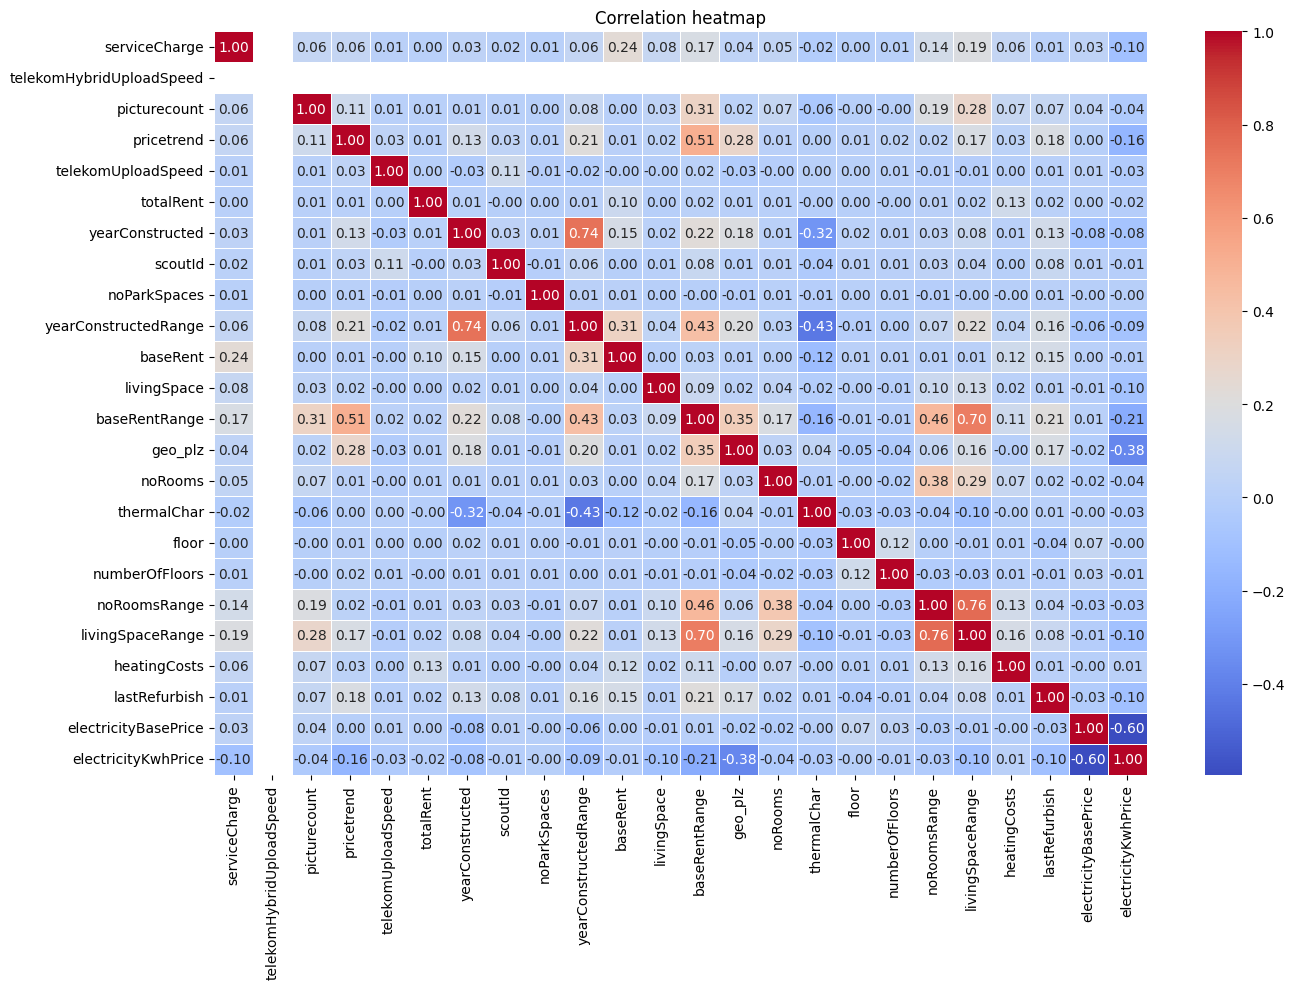

In [25]:
numeric_df = df.select_dtypes(include='number') #pick only numeric column
corr_matrix = numeric_df.corr() #calcule Corr between each pair

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

2. *Scatterplot* of **living space vs total rent for Berlin**

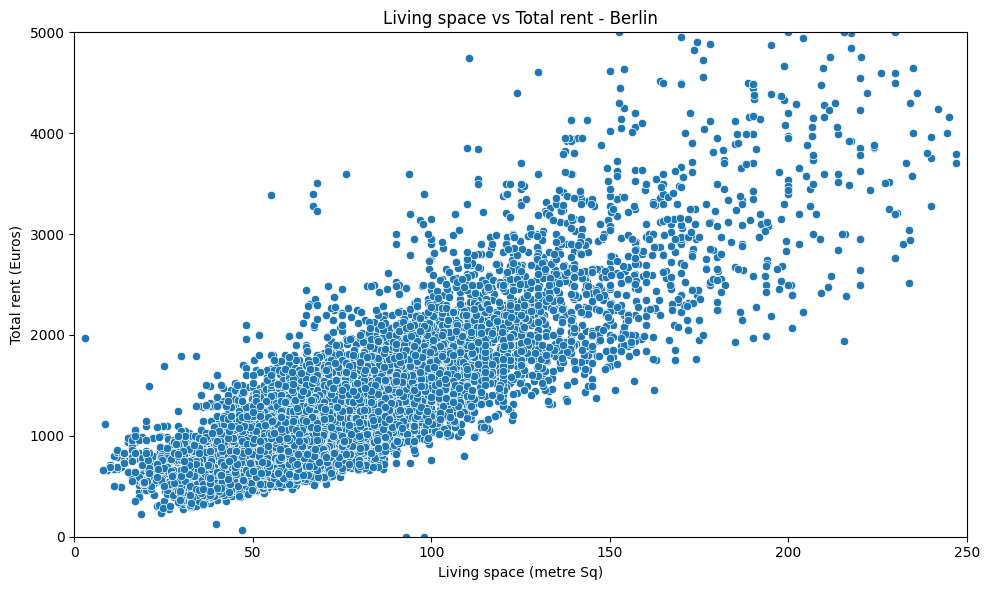

In [31]:
berlin_df = df[df['regio1'] == 'Berlin'] # filter only berlin

plt.figure(figsize=(10, 6))
sns.scatterplot(data=berlin_df, x='livingSpace', y='totalRent')
plt.title('Living space vs Total rent - Berlin')
plt.xlabel('Living space (metre Sq)')
plt.ylabel('Total rent (Euros)')

plt.xlim(0, 250)
plt.ylim(0, 5000)
plt.tight_layout()
plt.show()


3. *Histogram* of **total rent values** for Berlin

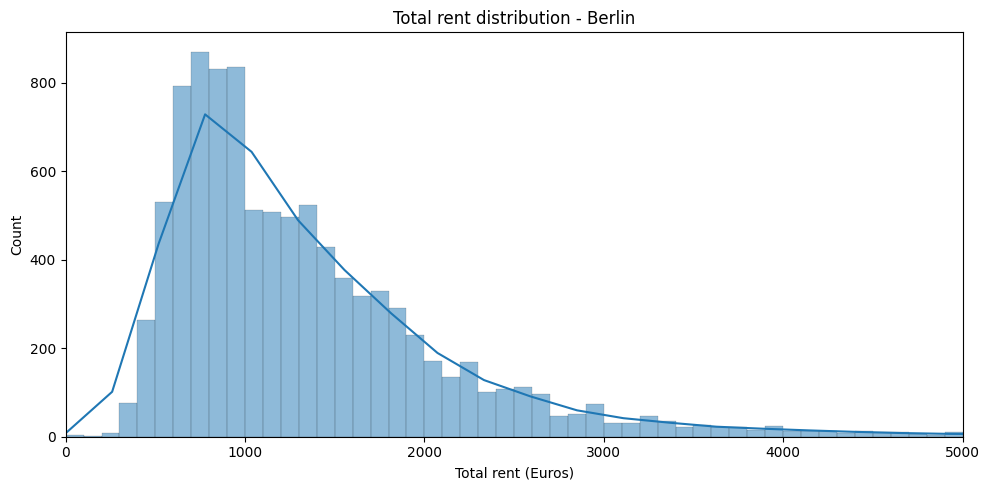

In [32]:
plt.figure(figsize=(10, 5))
sns.histplot(data=berlin_df, x='totalRent', bins=50, kde=True ,binrange=(0, 5000))
plt.title('Total rent distribution - Berlin')
plt.xlabel('Total rent (Euros)')
plt.xlim(0, 5000)
plt.tight_layout()
plt.show()